CSV conversion completed


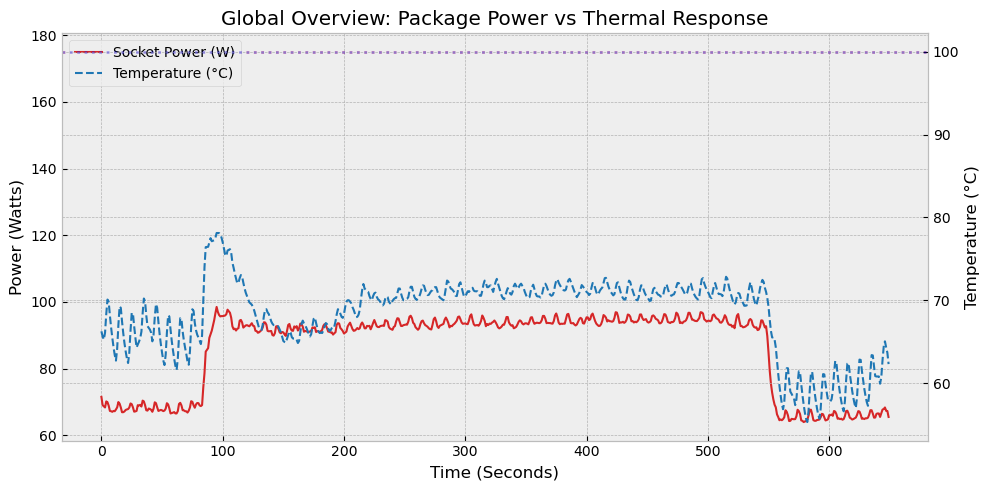

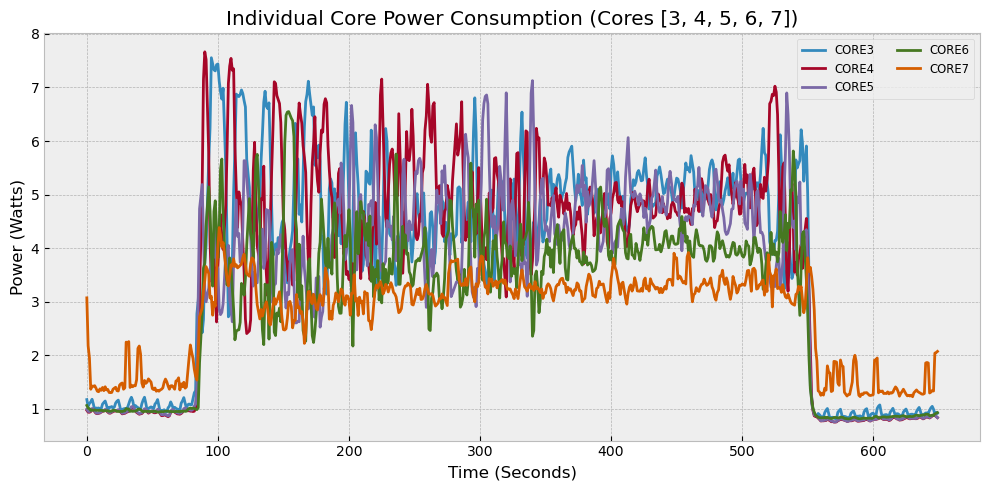

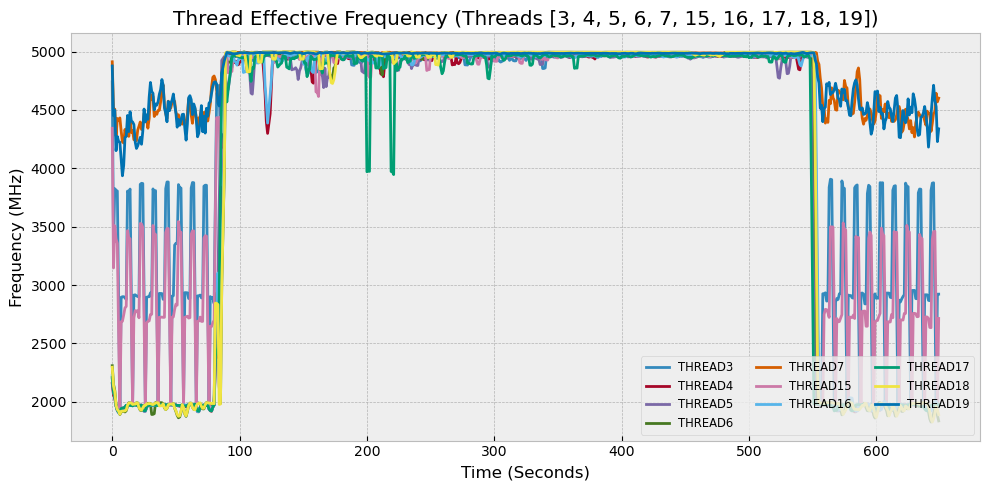

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

FILE_PATH = 'timechart.csv' # a measurement demo is provided alongside the notebook
OUTPUT_DIR = 'CSV' # standard CSVs with headers

SMOOTHING_WINDOW = 3
# reduces spikes revealing readings anomalies
REMOVE_SPIKES = True
SPIKE_PERCENTILE = 0.995

FIG_SIZE = (10, 5) # Plots effective size

# Selection filter (the actual cores and threads being effectively tracked, even if other ones are still recorded)
SELECTED_CORES = [3, 4, 5, 6, 7]
SELECTED_THREADS = [3, 4, 5, 6, 7, 15, 16, 17, 18, 19]

# Plots thresholds
THERMAL_LIMIT_C = 100.0
TDP_LIMIT_W = 175.0

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_and_process(filepath):
    # Dynamic detection of profiling records start line
    start_line = 0
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if "PROFILE RECORDS" in line:
                start_line = i + 1
                break

    df = pd.read_csv(filepath, skiprows=start_line, skipinitialspace=True)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Timestamp standardization
    df['TimeDelta'] = pd.to_timedelta(
        df['Timestamp'].str.replace(r':(\d+)$', r'.\1', regex=True)
    )

    # Calculate relative seconds for X-axis
    start_t = df['TimeDelta'].iloc[0]
    df['Seconds'] = (df['TimeDelta'] - start_t).dt.total_seconds()

    return df

df = load_and_process(FILE_PATH)

numeric_cols = df.select_dtypes(include=['float', 'int']).columns
cols_to_process = [c for c in numeric_cols if c not in ['Seconds', 'RecordId']]

# Clipping and smoothing (optional)
if REMOVE_SPIKES:
    for c in cols_to_process:
        upper_limit = df[c].quantile(SPIKE_PERCENTILE)
        # substitute measurement spikes
        df[c] = df[c].clip(upper=upper_limit)
if SMOOTHING_WINDOW > 1:
    df[cols_to_process] = df[cols_to_process].rolling(
        window=SMOOTHING_WINDOW, min_periods=1).mean()

power_core_cols = [c for c in df.columns if 'core' in c and 'power' in c]
freq_cols = [c for c in df.columns if 'frequency' in c]

# Clean CSVs in output
df_plot1 = df[['Seconds', 'socket0-package-power',
               'socket0-temperature']].copy()
df_plot1.to_csv(f'{OUTPUT_DIR}/global.csv', index=False)

target_power_cols = [c for c in power_core_cols if any(
    f"core{i}-" in c for i in SELECTED_CORES)]
df_plot2 = df[['Seconds'] + target_power_cols].copy()
df_plot2.to_csv(f'{OUTPUT_DIR}/cores.csv', index=False)

target_freq_cols = [c for c in freq_cols if any(
    f"thread{i}-" in c for i in SELECTED_THREADS)]
df_plot3 = df[['Seconds'] + target_freq_cols].copy()
df_plot3.to_csv(f'{OUTPUT_DIR}/threads.csv', index=False)

print("CSV conversion completed")

# Visualization
plt.style.use('bmh')

# Global overview
fig1, ax1 = plt.subplots(figsize=FIG_SIZE)
ax1_twin = ax1.twinx()

p1 = ax1.plot(df['Seconds'], df['socket0-package-power'],
              color='#d62728', label='Socket Power (W)', linewidth=1.5)
p2 = ax1_twin.plot(df['Seconds'], df['socket0-temperature'], color='#1f77b4',
                   label='Temperature (°C)', linewidth=1.5, linestyle='--')

ax1.axhline(y=TDP_LIMIT_W, color='red', alpha=0.3,
            linestyle=':', label='TDP Limit')
ax1_twin.axhline(y=THERMAL_LIMIT_C, color='blue', alpha=0.3,
                 linestyle=':', label='Thermal Limit')

ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('Power (Watts)')
ax1_twin.set_ylabel('Temperature (°C)')
ax1.set_title('Global Overview: Package Power vs Thermal Response')

lines = p1 + p2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout()
plt.show()

# Core power breakdown
fig2, ax2 = plt.subplots(figsize=FIG_SIZE)
for col in target_power_cols:
    ax2.plot(df['Seconds'], df[col], label=col.replace('-power', '').upper())

ax2.set_xlabel('Time (Seconds)')
ax2.set_ylabel('Power (Watts)')
ax2.set_title(f'Individual Core Power Consumption (Cores {SELECTED_CORES})')
ax2.legend(loc='upper right', ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

# Effective threads frequency
fig3, ax3 = plt.subplots(figsize=FIG_SIZE)
for col in target_freq_cols:
    ax3.plot(df['Seconds'], df[col], label=col.replace(
        '-core-effective-frequency', '').upper())

ax3.set_xlabel('Time (Seconds)')
ax3.set_ylabel('Frequency (MHz)')
ax3.set_title(f'Thread Effective Frequency (Threads {SELECTED_THREADS})')
ax3.legend(loc='lower right', ncol=3, fontsize='small')
plt.tight_layout()
plt.show()